In [2]:
cd /Users/nte/Documents/Chicago\ PhD\ Projects/Political\ culture\ maps/1.ANALYSIS


[WinError 3] The system cannot find the path specified: '/Users/nte/Documents/Chicago\\ PhD\\ Projects/Political\\ culture\\ maps/1.ANALYSIS'
c:\Users\asarr\Documents\Projects\pol_cul_maps_LA


!/usr/bin/env python coding: utf-8
Culture Maps Project

## Author: Nicolás Torres-Echeverry
## Created: July 2021
## Date(last modified): July 20th 2023
## Data storage: 
    ### Merges website's source data (from csv) and text data dictionary (from json) and saves it as a csv. 
    ### It allows to create different data frames filtering by the number of words (e.g., all websites with less than 3k)
## Working with El Corpus del Español

## Notebook index:
    # 1. Libraries
    # 2. Helper functions
    # 3. Pipeline
    # 4. Save data frame as csv

# 1. Libraries

In [21]:
# # 1. Libraries 

import pandas as pd
import numpy as np
import json
import re


# 2. Helper functions

In [22]:
def creates_df(source_df, websites_text, max_words, full_data=False):
    '''
    Merges source data (DataFrame) and websites text data (dictionary) and creates a 
    pandas dataframe. 
    
    Inputs:
        source_df: (DataFrame) DataFrame with websites URLs and text IDs.
        websites_text: (dictionary) 
                    key - (str) id (text ID as string)
                    value - (string) websites' texts 
        max_words: (int) Cutoff for the number of words allowed per website. 
        full_data: (boolean) If TRUE, returns the entire data frame with NAs for missing texts.
                             If FALSE, returns only rows with text. Default is FALSE.
    
    Output:
        DataFrame based on full_data argument:
        - If full_data=True, returns a DataFrame with missing values (NAs) for websites that exceed max_words.
        - If full_data=False, returns a DataFrame without missing values (only rows with valid text).
    '''
    
    span_df = source_df.copy()
    
    # Initialize empty columns for 'text' and 'id_string'
    span_df['text'] = np.nan
    span_df['id_string'] = span_df['textid'].astype(str)

    c = 0  # Counter for how many websites are included
    for index, row in span_df.iterrows():
        textid_value = row['id_string']
        if textid_value in websites_text:
            text = websites_text[textid_value]
            word_count = len(text.split())  # Count words
            if word_count < max_words:
                c += 1
                span_df.at[index, 'text'] = text
        # Otherwise, text remains np.nan
    
    if full_data:
        print("RETURNING FULL DATA FRAME")
        return span_df
    else:
        print("RETURNING SMALL DATA FRAME. NO NAs.") 
        smaller_df = span_df.dropna(subset=['text'])
        print("Number of website texts included in data frame:", c)
        return smaller_df

In [3]:
def count_matches(source_list, websites_text):
    '''
    Inpputs:
        source_list: (list) websites urls
        websites_text: (dictionary) 
                    key - (int) id
                    value - (string) websites' texts 
    Output:
        c: (int) count of matches
    '''
    
    c = 0
    
    for index, row in source_list.iterrows():
        textid_value = row['id_string']
        if textid_value in websites_text:
            c = c + 1

    print("Number of matches: ids both in dicitonary and source:", c)

    return c
    

# 3. Pipeline

In [12]:
# Reading json 

json_file = r"../data/dict_span_full.json"

with open(json_file, "r") as read_file:
    dict_text_websites = json.load(read_file)


In [4]:
# File path
file_path = '../data/sources_csv.csv'

# Read the CSV file into a pandas DataFrame
df_sources = pd.read_csv(file_path)

In [5]:
df_sources.columns

Index(['textid', 'words_number', 'genre', 'country', 'website', 'url',
       'title'],
      dtype='object')

In [6]:
df_sources.shape

(2096913, 7)

In [23]:
df = creates_df(df_sources, dict_text_websites, 1000, full_data=False)

C:\Users\asarr\AppData\Local\Temp\ipykernel_89308\1107844766.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'septiembre . - El director general de Sustentabilidad de la Secretaría de Energía ( Sener   Efraín Villanueva Arcos  expresó su confianza en que México alcance las reformas que merece  como la energética  cuyo fin es el de una energía más eficiente y limpia . Entrevistado en el marco de el Foro de Sustentabilidad 2013 . Juntos por un planeta mejor  manifestó su beneplácito que en el marco de el análisis de esta reforma los empresarios estén planteando cadenas de valor y mayor integración nacional . Expresó que el objetivo es que el fortalecimiento de el sector energético se traduzca en mayor generación de empleos y  en consecuencia  haya más capacitación profesional que permita la mejora de ingresos en este sector . Respecto a la discusión de las energías renovables en leyes secundarias  conf

RETURNING SMALL DATA FRAME. NO NAs.
Number of website texts included in data frame: 1600134


Check if it works

<Axes: >

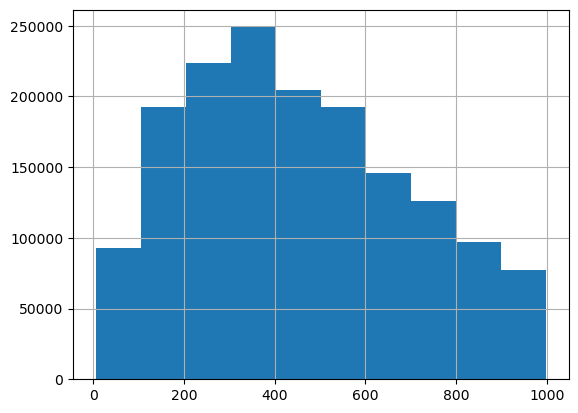

In [24]:
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
df['num_words'].hist()

In [25]:
df.to_csv('../data/span_full_text_1k_words.csv', index=False)

#### I was able to run the funciton and create an smaller data frame for websites with less than 1,000 words.

In [26]:
df_3k = creates_df(df_sources, dict_text_websites, 3000, full_data=False)
df_3k.to_csv('../data/span_full_text_3k_words.csv', index=False)

C:\Users\asarr\AppData\Local\Temp\ipykernel_89308\1107844766.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'julio de 2010 Olas de turistas canadienses  europeos y latinoamericanos no han cambiado nada Mary=Anastasia=O'Grady Hoy se marca el primer aniversario de la decisión de la Corte Suprema hondureña de ordenar el arresto de Manuel Zelaya  el seguidor de Hugo Chávez hambriento de poder que intentó ser presidente de por vida . Es algo para celebrar  gracias a la valentía de la Corte y el Congreso  que votó para remover lo de su cargo  se salvó la democracia . Sin embargo queda una pregunta irritante   por qué el gobierno de Barack Obama y legisladores estadounidenses clave estuvieron obsesionados  durante siete meses  con intentar obligar a Honduras a reinstalar a Zelaya   Por qué EE.UU. retiró visas  negó ayuda y lideró una campaña internacional para aislar a la diminuta democracia centroamerican

RETURNING SMALL DATA FRAME. NO NAs.
Number of website texts included in data frame: 1995004


In [27]:
df_5k = creates_df(df_sources, dict_text_websites, 5000, full_data=False)
df_5k.to_csv('../data/span_full_text_5k_words.csv', index=False)

C:\Users\asarr\AppData\Local\Temp\ipykernel_89308\1107844766.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'julio de 2010 Olas de turistas canadienses  europeos y latinoamericanos no han cambiado nada Mary=Anastasia=O'Grady Hoy se marca el primer aniversario de la decisión de la Corte Suprema hondureña de ordenar el arresto de Manuel Zelaya  el seguidor de Hugo Chávez hambriento de poder que intentó ser presidente de por vida . Es algo para celebrar  gracias a la valentía de la Corte y el Congreso  que votó para remover lo de su cargo  se salvó la democracia . Sin embargo queda una pregunta irritante   por qué el gobierno de Barack Obama y legisladores estadounidenses clave estuvieron obsesionados  durante siete meses  con intentar obligar a Honduras a reinstalar a Zelaya   Por qué EE.UU. retiró visas  negó ayuda y lideró una campaña internacional para aislar a la diminuta democracia centroamerican

RETURNING SMALL DATA FRAME. NO NAs.
Number of website texts included in data frame: 2044408


In [28]:
df_10k = creates_df(df_sources, dict_text_websites, 10000, full_data=False)
df_10k.to_csv('../data/span_full_text_10k_words.csv', index=False)

C:\Users\asarr\AppData\Local\Temp\ipykernel_89308\1107844766.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'julio de 2010 Olas de turistas canadienses  europeos y latinoamericanos no han cambiado nada Mary=Anastasia=O'Grady Hoy se marca el primer aniversario de la decisión de la Corte Suprema hondureña de ordenar el arresto de Manuel Zelaya  el seguidor de Hugo Chávez hambriento de poder que intentó ser presidente de por vida . Es algo para celebrar  gracias a la valentía de la Corte y el Congreso  que votó para remover lo de su cargo  se salvó la democracia . Sin embargo queda una pregunta irritante   por qué el gobierno de Barack Obama y legisladores estadounidenses clave estuvieron obsesionados  durante siete meses  con intentar obligar a Honduras a reinstalar a Zelaya   Por qué EE.UU. retiró visas  negó ayuda y lideró una campaña internacional para aislar a la diminuta democracia centroamerican

RETURNING SMALL DATA FRAME. NO NAs.
Number of website texts included in data frame: 2073216


### Great! this is a larger dataframe than the one I had. It has 1,016,208

In [ ]:
# checkpoint (if needed)

# count = count_matches(df_sources, dict_text_websites) 

### Interesting! From 21593 websites in the dictionary 21582 make match in the source!

# 4. Saves data frame

In [13]:
df.to_csv('span_full_text_1k_words.csv')

In [14]:
df_3k.to_csv('span_full_text_3k_words.csv')